In [1]:
import matplotlib.pyplot as plt
import numpy as np
import kornia
import torch
import torch.nn.functional as tf
%run a2_script.ipynb

#### Sorry it seems the plt logic is not correctly executed
when directly calling MyCannyFull(), the result edge image somehow colliding with some other image.
The following is an extraction of the code executing from start to the end of MyCannyFull(). And in the middle you can see the clear edge Hysteresis thresholding image, at high_max_ratio of 0.05

torch.Size([1, 3, 1312, 1600])
torch.Size([1, 1, 1312, 1600])


Text(0.5, 1.0, 'Grayscale image')

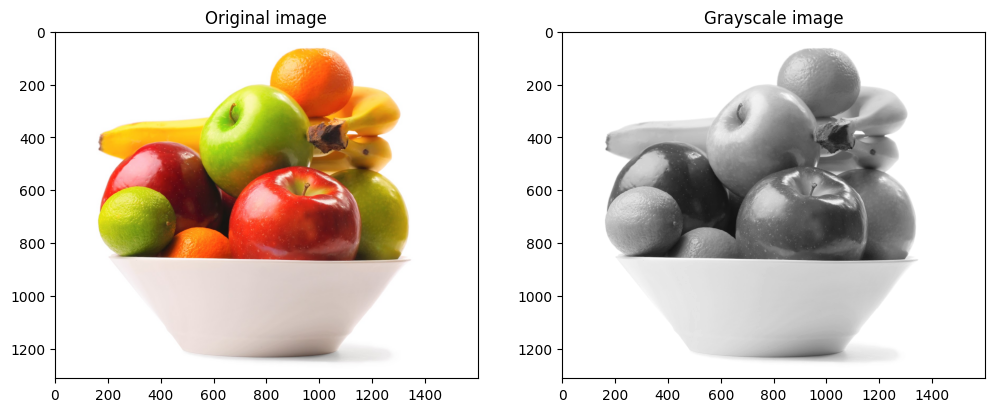

In [2]:
img = plt.imread("bowl-of-fruit.jpg").astype(np.float32) / 255
img_t = np.transpose(img, (2,0,1))

# img_gray = img[:, :, 0]*0.299 + img[:, :, 1]*0.587 + img[:, :, 2]*0.114
# create grayscale image
img_tensor = torch.from_numpy(img_t).unsqueeze(0)
print(img_tensor.shape)
img_gray = kornia.color.rgb_to_grayscale(img_tensor)
print(img_gray.size())

# show image input
_, (g0, g1) = plt.subplots(1,2, sharex=True, figsize=(12,5))
g0.imshow(img)
g0.set_title("Original image")
g1.imshow(img_gray.squeeze(), cmap="gray")
g1.set_title("Grayscale image")

torch.Size([1, 1, 1312, 1600]) torch.Size([1, 1, 1312, 1600])


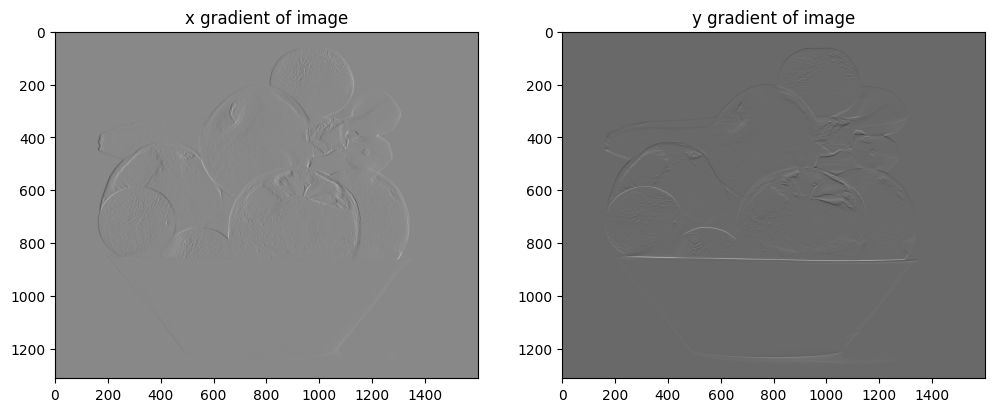

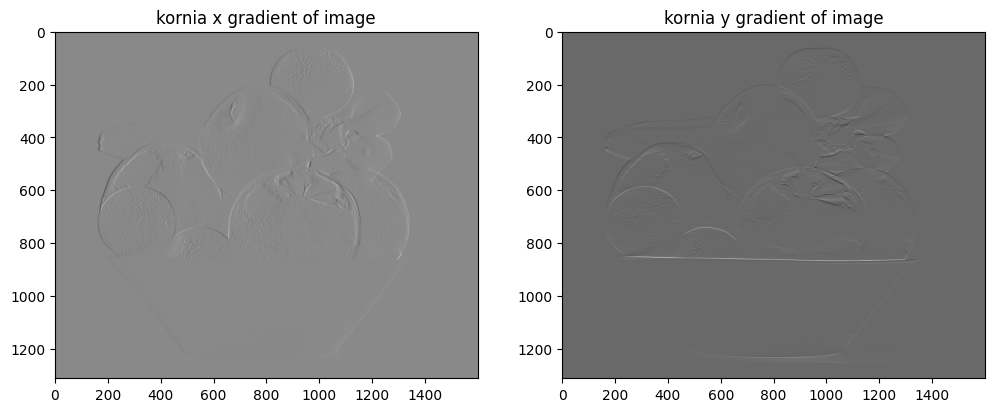

In [3]:
Ix, Iy = gauss_derivative_filtering(img_gray, 3, 1)
print(Ix.shape, Iy.shape)
# example x, y gradient with kornia sobel filter, and compare with native gradient filter
example = kornia.filters.spatial_gradient(img_gray, mode='sobel')
eg_x, eg_y = torch.split(example, 1, dim=2)

# show temporal results
imshow_row2(Ix, Iy, "x gradient of image", "y gradient of image", "gray")
imshow_row2(eg_x, eg_y, "kornia x gradient of image", "kornia y gradient of image", "gray")

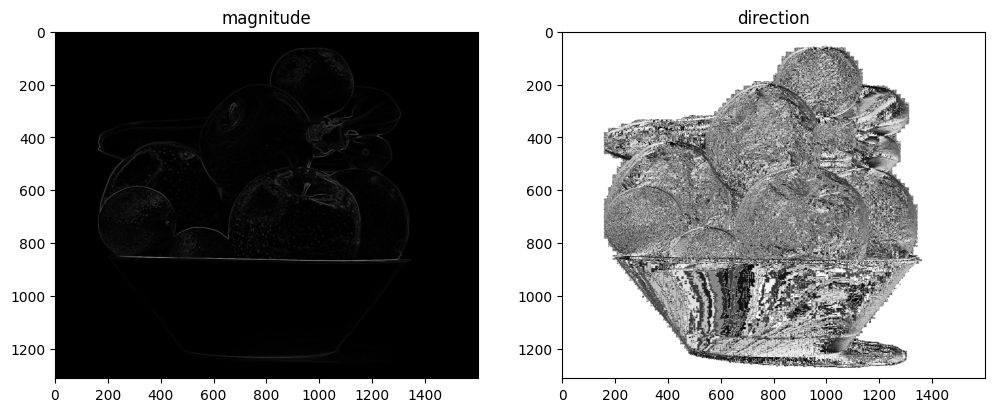

In [11]:
magnitude = torch.sqrt(torch.square(Ix) + torch.square(Iy))
direction = torch.atan(Iy / Ix).nan_to_num_()
imshow_row2(magnitude.squeeze(), direction.squeeze(), "magnitude", "direction", "gray")

In [5]:
r0_up = torch.roll(magnitude, -1, dims=2)
r0_up[..., -1, :] = r0_up[..., -2, :]

r1_lu = torch.roll(magnitude, (-1, -1), dims=(2,3))
r1_lu[..., -1, :] = r1_lu[..., -2, :]
r1_lu[..., -1] = r1_lu[..., -2]

r2_l = torch.roll(magnitude, -1, dims=3)
r2_l[..., -1] = r2_l[..., -2]

r3_ld = torch.roll(magnitude, (1, -1), dims=(2,3))
r3_ld[..., 0, :] = r3_ld[..., 1, :]
r3_ld[..., -1] = r3_ld[..., -2]

r0 = torch.where(direction==0, r0_up, 0)
r1 = torch.where(direction==1, r1_lu, 0)
r2 = torch.where(direction==2, r2_l, 0)
r3 = torch.where(direction==3, r3_ld, 0)

l0_down = torch.roll(magnitude, 1, dims=2)
l0_down[..., 0, :] = l0_down[..., 1, :]

l1_rd = torch.roll(magnitude, (1, 1), dims=(2,3))
l1_rd[..., 0, :] = l1_rd[..., 1, :]
l1_rd[..., 0] = l1_rd[..., 1]

l2_r = torch.roll(magnitude, 1, dims=3)
l2_r[..., 0] = l2_r[..., 1]

l3_ru = torch.roll(magnitude, (-1, 1), dims=(2,3))
l3_ru[..., -1, :] = l3_ru[..., -2, :]
l3_ru[..., 0] = l3_ru[..., 1]

l0 = torch.where(direction==0, l0_down, 0)
l1 = torch.where(direction==1, l1_rd, 0)
l2 = torch.where(direction==2, l2_r, 0)
l3 = torch.where(direction==3, l3_ru, 0)

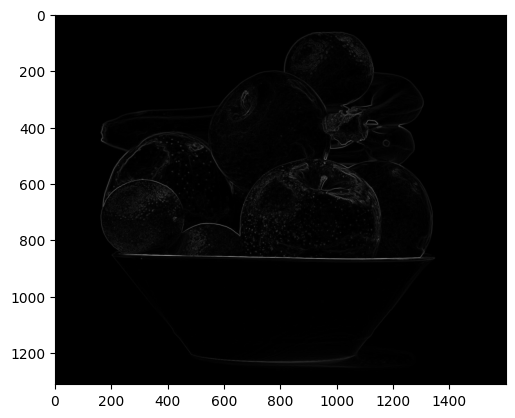

In [12]:
dire_pent = torch.div(direction.squeeze() + torch.pi*5/8, torch.pi/4, rounding_mode='floor').squeeze().int()
# truncate the same comparisons of top-down and down-top
dire_pent %= 4

right, left = r0+r1+r2+r3, l0+l1+l2+l3
NMS_bool = torch.logical_and(magnitude > right, magnitude >= left)
NMS = torch.where(NMS_bool, magnitude, 0)
plt.imshow(NMS.squeeze(), cmap='gray')

In [13]:
high_max_ratio = 0.05
edge = NMS
maximum = torch.max(edge)
print(maximum)
high = maximum * high_max_ratio
print(high)
hyst = torch.where(edge >= high, 1., 0.)
pad_hyst = tf.pad(hyst, [1,1,1,1], mode='constant', value=0.)

new_count = torch.sum(hyst == 1.)
count = 0
diff = new_count
p0 = pad_hyst[..., :-2, 1:-1]
p1 = pad_hyst[..., :-2, 2:]
p2 = pad_hyst[..., 1:-1, 2:]
p3 = pad_hyst[..., 2:, 2:]
p4 = pad_hyst[..., 2:, 1:-1]
p5 = pad_hyst[..., 2:, :-2]
p6 = pad_hyst[..., 1:-1, :-2]
p7 = pad_hyst[..., :-2, :-2]

tensor(0.2090)
tensor(0.0105)


tensor(102644)
tensor(97151)


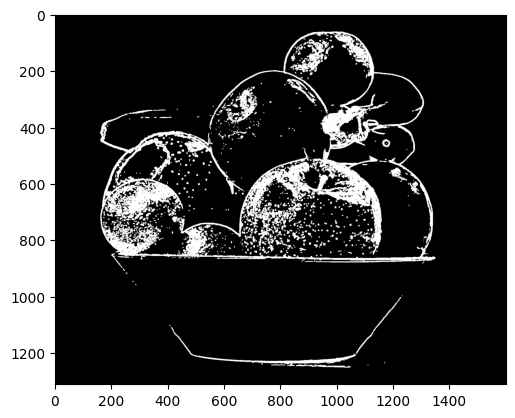

In [8]:
while diff:
    print(diff)
    count = new_count
    b0 = torch.logical_and(p0 == 1, edge > 0)
    b1 = torch.logical_and(p1 == 1, edge > 0)
    b2 = torch.logical_and(p2 == 1, edge > 0)
    b3 = torch.logical_and(p3 == 1, edge > 0)
    b4 = torch.logical_and(p4 == 1, edge > 0)
    b5 = torch.logical_and(p5 == 1, edge > 0)
    b6 = torch.logical_and(p6 == 1, edge > 0)
    b7 = torch.logical_and(p7 == 1, edge > 0)
    b01 = torch.logical_or(b0, b1)
    b23 = torch.logical_or(b2, b3)
    b45 = torch.logical_or(b4, b5)
    b67 = torch.logical_or(b6, b7)
    b03 = torch.logical_or(b01, b23)
    b47 = torch.logical_or(b45, b67)
    candidate = torch.logical_or(b03, b47)
    hyst = torch.where(candidate, 1., hyst)
    new_count = torch.sum(hyst == 1.)
    diff =  new_count - count
plt.imshow(hyst.squeeze(), cmap='gray')

tensor(42334)
tensor(9164)


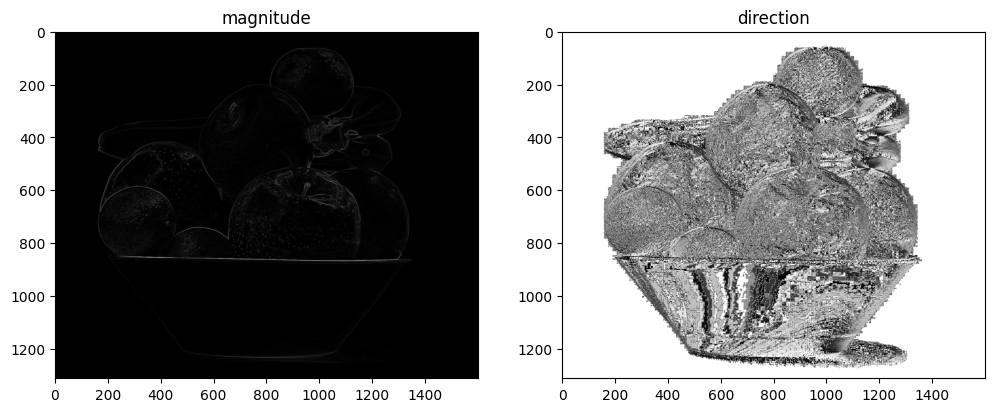

In [9]:
result = MyCannyFull(img_gray, 3, 0.05).squeeze()

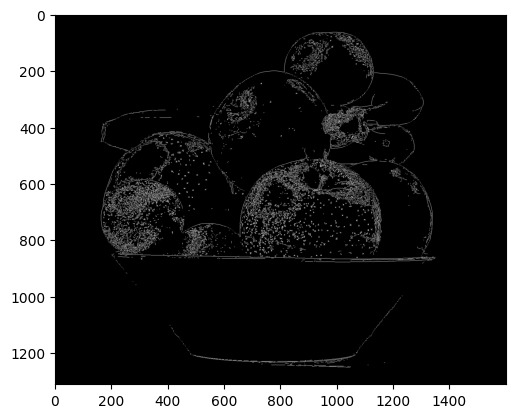

In [14]:
plt.imshow(result.squeeze(), cmap='gray')